# Product schedule frontiers with terminal washout

The retailer chooses promotions during a 12-week decision horizon.
Schedule value is then evaluated for an additional washout period in
which no new promotions are permitted:

\[
d_t=0,
\qquad
t=13,\ldots,12+H_w.
\]

This captures demand displaced beyond week 12 and removes the
artificial advantage of a terminal-week promotion. The primary
specification uses \(H_w=6\), with \(H_w\in\{0,4,6\}\) reported as a
sensitivity analysis.

## 1. Imports and paths

In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        root
        for root in [
            CURRENT_DIR,
            CURRENT_DIR.parent,
        ]
        if (
            root
            / "data"
            / "processed"
        ).is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate project root from {CURRENT_DIR}"
    )

SRC_DIR = PROJECT_ROOT / "src"

if str(
    SRC_DIR
) not in sys.path:
    sys.path.insert(
        0,
        str(
            SRC_DIR
        ),
    )

from tiny_paper_pipeline_v3 import (
    PlanningConfig,
    SupportedActionConfig,
    build_category_sensitivity_v2,
    build_product_schedule_artifact_v2,
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)
TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\janza\price-of-extrapolation


In [2]:
PRODUCT_DRAW_PATH = (
    PROCESSED_DIR
    / "product_stockpiling_behavioral_draws_v2.pkl"
)
PRODUCT_SUMMARY_PATH = (
    TABLE_DIR
    / "product_stockpiling_calibration_summary_v2.csv"
)
PRODUCT_ACTION_SUPPORT_PATH = (
    TABLE_DIR
    / "product_supported_action_clusters.csv"
)
PRODUCT_ACTION_SET_PATH = (
    PROCESSED_DIR
    / "product_supported_action_sets.pkl"
)

ARTIFACT_PATHS = {
    "empirical_w0": (
        PROCESSED_DIR
        / "product_schedule_artifact_empirical_w0.pkl"
    ),
    "empirical_w4": (
        PROCESSED_DIR
        / "product_schedule_artifact_empirical_w4.pkl"
    ),
    "empirical_w6": (
        PROCESSED_DIR
        / "product_schedule_artifact_empirical_w6.pkl"
    ),
    "common_0_30_w6": (
        PROCESSED_DIR
        / "product_schedule_artifact_common_0_30_w6.pkl"
    ),
}

FRONTIER_PATH = (
    TABLE_DIR
    / "product_schedule_frontiers_washout.csv"
)
ESCALATION_PATH = (
    TABLE_DIR
    / "product_escalation_thresholds_washout.csv"
)
PRODUCT_VDO_PATH = (
    TABLE_DIR
    / "product_vdo_washout_sensitivity.csv"
)
PRUNING_PATH = (
    TABLE_DIR
    / "product_schedule_pruning_washout.csv"
)

VDO_FIGURE_PATH = (
    FIGURE_DIR
    / "product_VDO_washout_sensitivity.png"
)
ESCALATION_FIGURE_PATH = (
    FIGURE_DIR
    / "product_escalation_washout6.png"
)

DECISION_HORIZON = 12
PRIMARY_WASHOUT = 6
WASHOUT_HORIZONS = (
    0,
    4,
    6,
)
MAIN_ALPHA = 2.24

base_planning_config = (
    PlanningConfig(
        horizon=(
            DECISION_HORIZON
        ),
        washout_horizon=(
            PRIMARY_WASHOUT
        ),
        cooldown=2,
        max_promotions=4,
        discount_factor=0.995,
        alpha_min=0.0,
        alpha_max=4.0,
        alpha_step=0.01,
    )
)
support_config = (
    SupportedActionConfig(
        minimum_observations=15,
        minimum_panels=3,
        maximum_positive_actions=3,
        matching_tolerance=0.03,
    )
)

## 2. Load calibrated products and action sets

In [3]:
required_paths = [
    PRODUCT_DRAW_PATH,
    PRODUCT_SUMMARY_PATH,
    PRODUCT_ACTION_SUPPORT_PATH,
    PRODUCT_ACTION_SET_PATH,
]

missing = [
    path
    for path in (
        required_paths
    )
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(
        "Run notebook 07b first. Missing: "
        + ", ".join(
            str(
                path
            )
            for path in (
                missing
            )
        )
    )

product_draws = pd.read_pickle(
    PRODUCT_DRAW_PATH
)
product_summary = pd.read_csv(
    PRODUCT_SUMMARY_PATH
)
support_table = pd.read_csv(
    PRODUCT_ACTION_SUPPORT_PATH
)
action_artifact = pd.read_pickle(
    PRODUCT_ACTION_SET_PATH
)

supported_action_sets = (
    action_artifact[
        "supported_action_sets"
    ]
)
products = (
    product_summary[
        "upc"
    ]
    .astype(
        str
    )
    .tolist()
)
common_action_sets = {
    upc: (
        0.00,
        0.10,
        0.20,
        0.30,
    )
    for upc in products
}

## 3. Build washout-corrected product schedule systems

In [4]:
artifacts = {}

for washout_horizon in (
    WASHOUT_HORIZONS
):
    grid_name = (
        f"empirical_w"
        f"{washout_horizon}"
    )
    planning_config = replace(
        base_planning_config,
        washout_horizon=(
            washout_horizon
        ),
    )
    artifacts[
        grid_name
    ] = (
        build_product_schedule_artifact_v2(
            product_draws=(
                product_draws
            ),
            product_summary=(
                product_summary
            ),
            support_table=(
                support_table
            ),
            product_action_sets=(
                supported_action_sets
            ),
            planning_config=(
                planning_config
            ),
            support_config=(
                support_config
            ),
            grid_name=(
                grid_name
            ),
        )
    )

common_config = replace(
    base_planning_config,
    washout_horizon=(
        PRIMARY_WASHOUT
    ),
)
artifacts[
    "common_0_30_w6"
] = (
    build_product_schedule_artifact_v2(
        product_draws=(
            product_draws
        ),
        product_summary=(
            product_summary
        ),
        support_table=(
            support_table
        ),
        product_action_sets=(
            common_action_sets
        ),
        planning_config=(
            common_config
        ),
        support_config=(
            support_config
        ),
        grid_name=(
            "common_0_30_w6"
        ),
    )
)

for grid_name, artifact in (
    artifacts.items()
):
    print(
        grid_name,
        "decision horizon =",
        artifact[
            "planning_config"
        ].horizon,
        "washout =",
        artifact[
            "planning_config"
        ].washout_horizon,
        "evaluation horizon =",
        (
            artifact[
                "planning_config"
            ].horizon
            + artifact[
                "planning_config"
            ].washout_horizon
        ),
    )

empirical_w0 decision horizon = 12 washout = 0 evaluation horizon = 12
empirical_w4 decision horizon = 12 washout = 4 evaluation horizon = 16
empirical_w6 decision horizon = 12 washout = 6 evaluation horizon = 18
common_0_30_w6 decision horizon = 12 washout = 6 evaluation horizon = 18


## 4. Compare VDO, escalation, and candidate pruning

In [5]:
frontier_frames = []
escalation_frames = []
vdo_frames = []
pruning_rows = []

for grid_name, artifact in (
    artifacts.items()
):
    planning_config = artifact[
        "planning_config"
    ]
    frontier = artifact[
        "frontier_table"
    ].copy()
    escalation = artifact[
        "escalation_table"
    ].copy()
    product_vdo = artifact[
        "product_vdo"
    ].copy()

    for frame in [
        frontier,
        escalation,
        product_vdo,
    ]:
        frame[
            "decision_horizon"
        ] = planning_config.horizon
        frame[
            "washout_horizon"
        ] = (
            planning_config.washout_horizon
        )
        frame[
            "evaluation_horizon"
        ] = (
            planning_config.horizon
            + planning_config.washout_horizon
        )

    frontier_frames.append(
        frontier
    )
    escalation_frames.append(
        escalation
    )
    vdo_frames.append(
        product_vdo
    )

    for upc in artifact[
        "products"
    ]:
        product = artifact[
            "product_artifacts"
        ][
            upc
        ]
        feasible_count = len(
            product[
                "schedules"
            ]
        )
        retained_count = len(
            product[
                "retained_indices"
            ]
        )

        pruning_rows.append(
            {
                "grid_name": (
                    grid_name
                ),
                "decision_horizon": (
                    planning_config.horizon
                ),
                "washout_horizon": (
                    planning_config.washout_horizon
                ),
                "evaluation_horizon": (
                    planning_config.horizon
                    + planning_config.washout_horizon
                ),
                "upc": (
                    upc
                ),
                "product_name": (
                    artifact[
                        "product_names"
                    ][
                        upc
                    ]
                ),
                "actions": (
                    "|".join(
                        f"{action:.2f}"
                        for action in (
                            product[
                                "actions"
                            ]
                        )
                    )
                ),
                "feasible_schedule_count": (
                    feasible_count
                ),
                "retained_candidate_count": (
                    retained_count
                ),
                "retained_share": (
                    retained_count
                    / feasible_count
                ),
            }
        )

combined_frontier = pd.concat(
    frontier_frames,
    ignore_index=True,
)
combined_escalation = pd.concat(
    escalation_frames,
    ignore_index=True,
)
combined_vdo = pd.concat(
    vdo_frames,
    ignore_index=True,
)
pruning_summary = pd.DataFrame(
    pruning_rows
)

vdo_washout = (
    combined_vdo.loc[
        combined_vdo[
            "grid_name"
        ].str.startswith(
            "empirical_w"
        )
    ][
        [
            "grid_name",
            "washout_horizon",
            "upc",
            "product_name",
            "value_of_dynamic_optimization",
            "dynamic_promotion_count",
            "myopic_promotion_count",
        ]
    ]
    .sort_values(
        [
            "upc",
            "washout_horizon",
        ]
    )
)

display(
    vdo_washout
)
display(
    combined_escalation.loc[
        combined_escalation[
            "grid_name"
        ].isin(
            [
                "empirical_w6",
                "common_0_30_w6",
            ]
        )
    ]
)
display(
    pruning_summary
)

,grid_name,washout_horizon,upc,product_name,value_of_dynamic_optimization,dynamic_promotion_count,myopic_promotion_count
5,empirical_w0,0,1600066510,1600066510,3.102702,4,4
13,empirical_w4,4,1600066510,1600066510,0.497885,4,4
21,empirical_w6,6,1600066510,1600066510,0.352480,4,4
1,empirical_w0,0,1600066590,1600066590,0.000000,0,0
9,empirical_w4,4,1600066590,1600066590,0.000000,0,0
17,empirical_w6,6,1600066590,1600066590,0.000000,0,0
0,empirical_w0,0,1600066610,1600066610,0.000000,0,0
8,empirical_w4,4,1600066610,1600066610,0.000000,0,0
16,empirical_w6,6,1600066610,1600066610,0.000000,0,0
7,empirical_w0,0,3800000110,3800000110,0.578394,4,4


,grid_name,upc,product_name,alpha_1_promotions,alpha_2_promotions,alpha_4_promotions,decision_horizon,washout_horizon,evaluation_horizon
16,empirical_w6,1600066610,1600066610,2.66,2.66,2.66,12,6,18
17,empirical_w6,1600066590,1600066590,2.59,2.59,2.60,12,6,18
18,empirical_w6,3800000120,3800000120,1.65,1.65,1.66,12,6,18
19,empirical_w6,3800001520,3800001520,2.80,2.82,2.85,12,6,18
20,empirical_w6,3800000127,3800000127,2.19,2.19,2.20,12,6,18
21,empirical_w6,1600066510,1600066510,1.90,1.91,1.91,12,6,18
22,empirical_w6,3800001611,3800001611,2.67,2.68,2.68,12,6,18
23,empirical_w6,3800000110,3800000110,1.54,1.56,1.58,12,6,18
24,common_0_30_w6,1600066610,1600066610,2.71,2.71,2.72,12,6,18
25,common_0_30_w6,1600066590,1600066590,2.62,2.63,2.64,12,6,18


,grid_name,decision_horizon,washout_horizon,evaluation_horizon,upc,product_name,actions,feasible_schedule_count,retained_candidate_count,retained_share
0,empirical_w0,12,0,12,1600066610,1600066610,0.00|0.05|0.25|0.50,3169,528,0.166614
1,empirical_w0,12,0,12,1600066590,1600066590,0.00|0.06|0.25|0.50,3169,547,0.172610
2,empirical_w0,12,0,12,3800000120,3800000120,0.00|0.04|0.30|0.55,3169,789,0.248974
3,empirical_w0,12,0,12,3800001520,3800001520,0.00|0.04|0.19|0.49,3169,528,0.166614
4,empirical_w0,12,0,12,3800000127,3800000127,0.00|0.05|0.30|0.50,3169,500,0.157778
5,empirical_w0,12,0,12,1600066510,1600066510,0.00|0.06|0.25|0.50,3169,528,0.166614
6,empirical_w0,12,0,12,3800001611,3800001611,0.00|0.05|0.09|0.40,3169,461,0.145472
7,empirical_w0,12,0,12,3800000110,3800000110,0.00|0.07|0.09,893,459,0.513998
8,empirical_w4,12,4,16,1600066610,1600066610,0.00|0.05|0.25|0.50,3169,460,0.145156
9,empirical_w4,12,4,16,1600066590,1600066590,0.00|0.06|0.25|0.50,3169,459,0.144841


## 5. Washout diagnostics

,washout_horizon,aggregate_product_VDO,change_from_no_washout
0,0,6.582763,0.000000
1,4,0.852871,-5.729892
2,6,0.557088,-6.025675


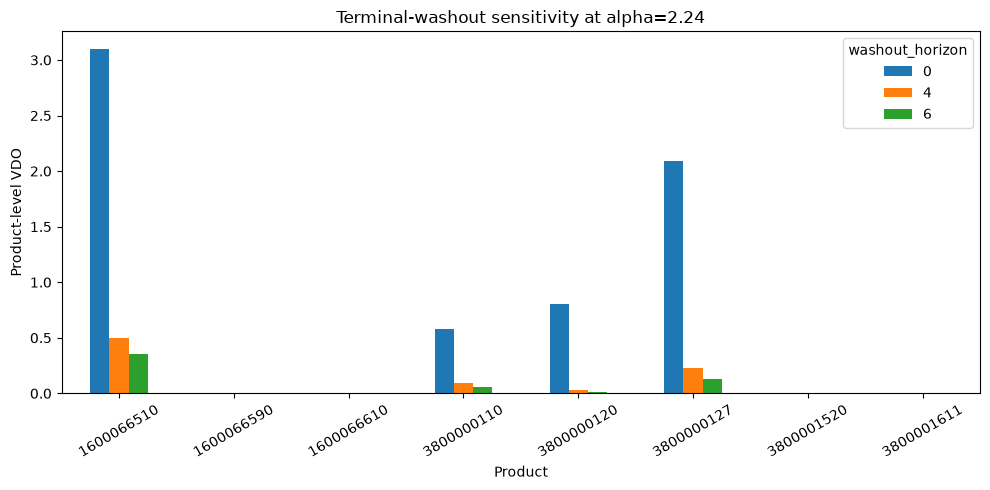

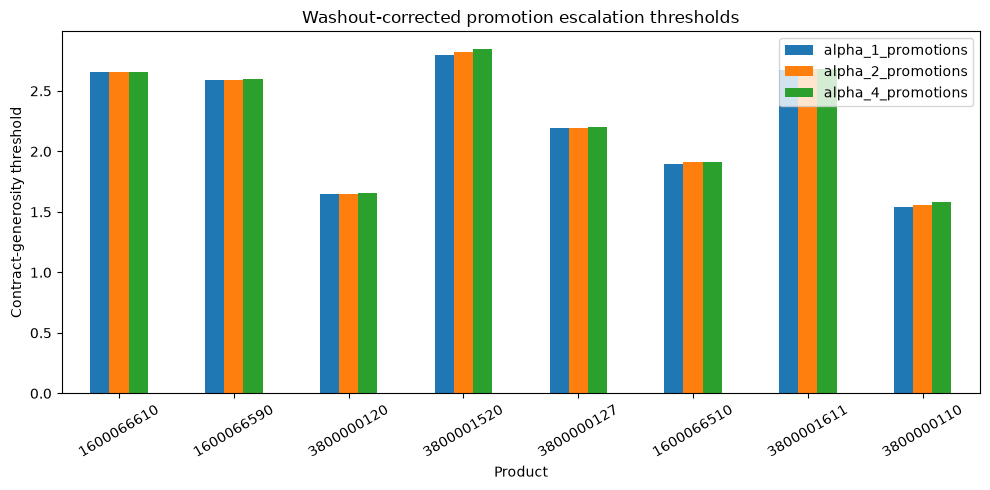

In [6]:
aggregate_vdo = (
    vdo_washout.groupby(
        "washout_horizon",
        observed=True,
    )[
        "value_of_dynamic_optimization"
    ]
    .sum()
    .rename(
        "aggregate_product_VDO"
    )
    .reset_index()
)

aggregate_vdo[
    "change_from_no_washout"
] = (
    aggregate_vdo[
        "aggregate_product_VDO"
    ]
    - aggregate_vdo.loc[
        aggregate_vdo[
            "washout_horizon"
        ].eq(
            0
        ),
        "aggregate_product_VDO",
    ].iloc[
        0
    ]
)

display(
    aggregate_vdo
)

figure_table = (
    vdo_washout.pivot_table(
        index=(
            "product_name"
        ),
        columns=(
            "washout_horizon"
        ),
        values=(
            "value_of_dynamic_optimization"
        ),
        aggfunc="first",
    )
)

fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)
figure_table.plot(
    kind="bar",
    ax=ax,
)
ax.set_xlabel(
    "Product"
)
ax.set_ylabel(
    "Product-level VDO"
)
ax.set_title(
    "Terminal-washout sensitivity at alpha=2.24"
)
ax.tick_params(
    axis="x",
    rotation=30,
)
fig.tight_layout()
fig.savefig(
    VDO_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

escalation_primary = (
    combined_escalation.loc[
        combined_escalation[
            "grid_name"
        ].eq(
            "empirical_w6"
        )
    ]
    .set_index(
        "product_name"
    )[
        [
            "alpha_1_promotions",
            "alpha_2_promotions",
            "alpha_4_promotions",
        ]
    ]
)

fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)
escalation_primary.plot(
    kind="bar",
    ax=ax,
)
ax.set_xlabel(
    "Product"
)
ax.set_ylabel(
    "Contract-generosity threshold"
)
ax.set_title(
    "Washout-corrected promotion escalation thresholds"
)
ax.tick_params(
    axis="x",
    rotation=30,
)
fig.tight_layout()
fig.savefig(
    ESCALATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 6. Save washout-corrected artifacts

In [7]:
for grid_name, artifact in (
    artifacts.items()
):
    pd.to_pickle(
        artifact,
        ARTIFACT_PATHS[
            grid_name
        ],
    )

combined_frontier.to_csv(
    FRONTIER_PATH,
    index=False,
)
combined_escalation.to_csv(
    ESCALATION_PATH,
    index=False,
)
combined_vdo.to_csv(
    PRODUCT_VDO_PATH,
    index=False,
)
pruning_summary.to_csv(
    PRUNING_PATH,
    index=False,
)

print(
    "Primary empirical artifact:",
    ARTIFACT_PATHS[
        "empirical_w6"
    ],
)
print(
    "Primary common-grid artifact:",
    ARTIFACT_PATHS[
        "common_0_30_w6"
    ],
)

Primary empirical artifact: C:\Users\janza\price-of-extrapolation\data\processed\product_schedule_artifact_empirical_w6.pkl
Primary common-grid artifact: C:\Users\janza\price-of-extrapolation\data\processed\product_schedule_artifact_common_0_30_w6.pkl


## Interpretation guardrails

- Promotions are chosen only in weeks \(1,\ldots,12\).
- Weeks \(13,\ldots,18\) contain no new promotions but remain in the
  value function.
- The primary results use six washout weeks.
- The no-washout result is retained only to quantify the original
  terminal-boundary bias.
- The empirical and common grids remain different action designs, not
  nested treatment and control groups.